# Week 4 In-Class Activity

## Part I: Correlation

Building on what we covered in Week 3's in-class assessment, we will continue our examination of globally and annually averaged surface temperature. These are data from 1979-2025. 

First, we import the packages that we will need:

In [136]:
#  import packages
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
import matplotlib as mpl
mpl.rc('font',size=16) #  set default font size and weight for plots

In [137]:
#  Load data
filename = "CO2_T_TSI.csv"
data = np.genfromtxt(filename, dtype='str',delimiter = ',').T #I just transposed it to get each data component as it's own array
data = data.astype('float')

In [138]:
#  The first variable in "data" is the year
year = data[0]

In [139]:
print(year)

[1979. 1980. 1981. 1982. 1983. 1984. 1985. 1986. 1987. 1988. 1989. 1990.
 1991. 1992. 1993. 1994. 1995. 1996. 1997. 1998. 1999. 2000. 2001. 2002.
 2003. 2004. 2005. 2006. 2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014.
 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024. 2025.]


In [140]:
#  GISTEMP temperature anomalies in 100th's of degrees C
T = data[1]

This time, we will also read in data for the total solar irradiance (**TSI**), aka the solar constant. This is the amount of radiation that the Earth receives from the Sun.

In [141]:
#  Total Solar Irradiance (TSI), aka the Solar Constant (W/m2)
TSI = data[3]
#print(TSI)

Text(0.5, 1.0, '(b) Total Solar Irradiance (1979-2020)')

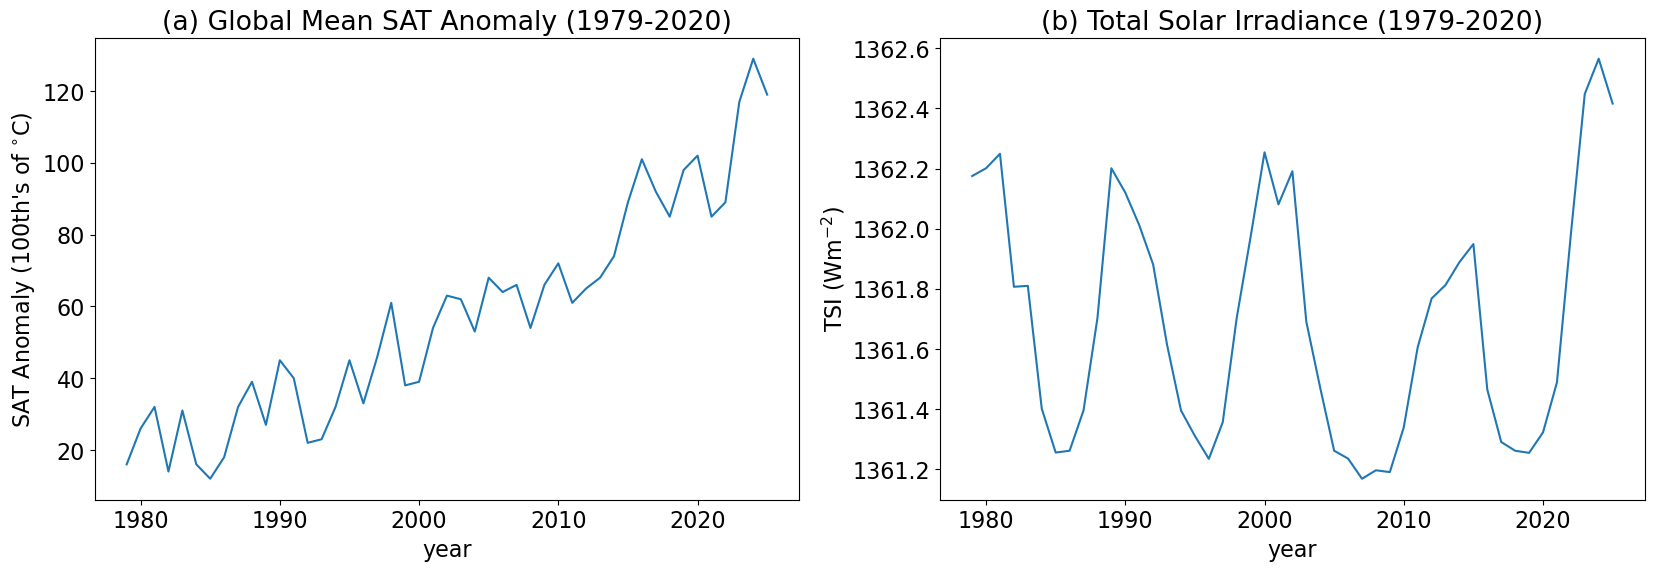

In [142]:
#  plot the time series of T and TSI.
#  uncomment the lines below, complete and beautify the plot, e.g. add labels, title, etc.

#  Let's use subplots!
plt.figure(figsize=(20,6))

#  Plot time series of T
plt.subplot(1,2,1)
plt.plot(year, T)
plt.xlabel("year")
plt.ylabel("SAT Anomaly (100th's of $^{\circ}$C)")
plt.title("(a) Global Mean SAT Anomaly (1979-2020)")

#  Plot time series of TSI
plt.subplot(1,2,2)
plt.plot(year,TSI)
plt.xlabel("year")
plt.ylabel("TSI (Wm$^{-2}$)")
plt.title("(b) Total Solar Irradiance (1979-2020)")

Note: you should be able to see an **11-year solar cycle in TSI**. Keep this in mind when you consider the issue of autocorrelation below.

Let's plot $T$ vs **TSI** in a scatter plot with the predictor and predictand variables on the x-axis and y-axis, respectively. 

**Reflection Question:**

Which do you think is the predictor and which is the predictand? Why?

Text(0, 0.5, "SAT Anomaly (100th's of $^{\\circ}$C)")

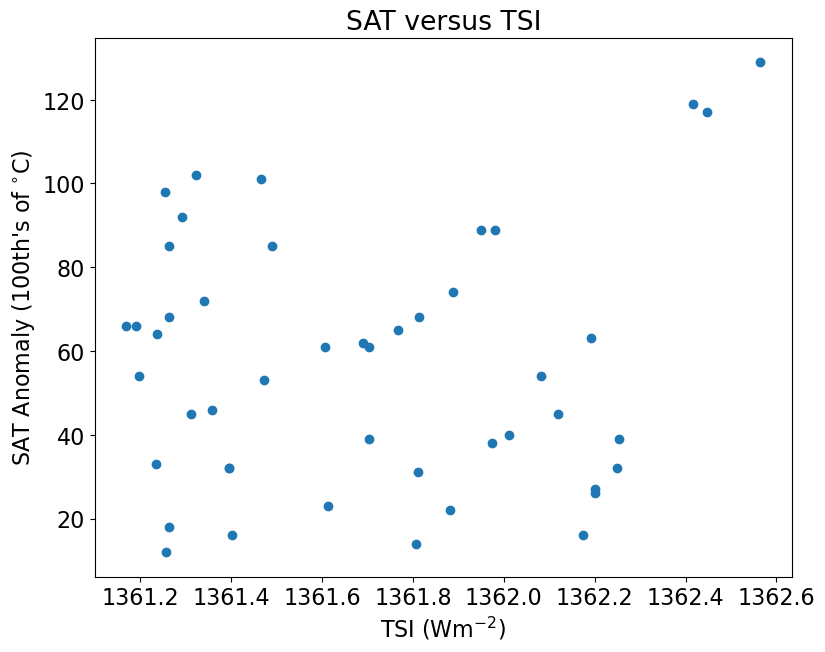

In [143]:
#  uncomment and fill in the lines below

plt.figure(figsize=(9,7))
plt.scatter(TSI,T)
plt.title("SAT versus TSI")
plt.xlabel("TSI (Wm$^{-2}$)")
plt.ylabel("SAT Anomaly (100th's of $^{\circ}$C)")

Let's calculate the best-fit line relating $T$ to **TSI** using `np.polyfit()` and `np.polyval()`. Note that the order that you input the variables matters: predictor first, then predictand.

In [144]:
# Uncomment and complete

a = np.polyfit(TSI, T,1)
print(a)

[ 8.06505579e+00 -1.09250614e+04]


Now, calculate the fitted values.

In [145]:
T_hat = np.polyval(a,TSI)

Let's add this best-fit line to our plot.

Text(0, 0.5, "SAT Anomaly (100th's of $^{\\circ}$C)")

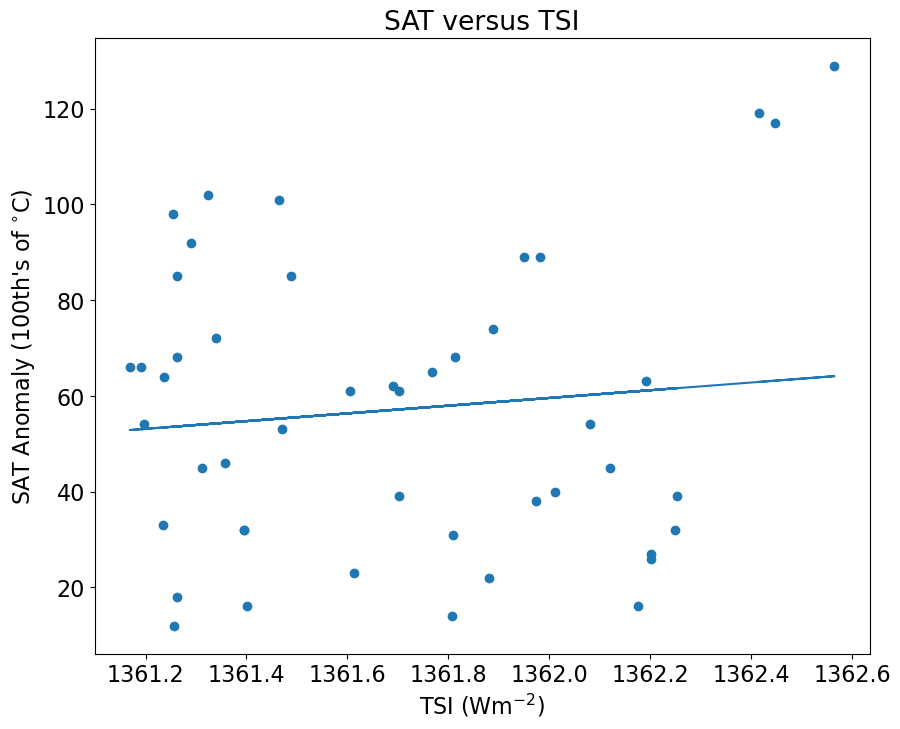

In [146]:
# Uncomment and fill in the lines below

plt.figure(figsize=(10,8))
plt.scatter(TSI,T)

# add best-fit line
plt.plot(TSI,T_hat)

plt.title("SAT versus TSI")
plt.xlabel("TSI (Wm$^{-2}$)")
plt.ylabel("SAT Anomaly (100th's of $^{\circ}$C)")

What is the correlation between temperature ($T$) and total solar irradiance (**TSI**)? We will use the `stats.pearsonr()` function to calculate the Pearson correlation coefficient.

In [147]:
#  uncomment and fill in the lines below

pcorr = stats.pearsonr(TSI,T)
print(pcorr)

PearsonRResult(statistic=0.10754653587559741, pvalue=0.47180883508165994)


In [148]:
# R-squared
pcorr[0]**2

0.011566257378841161

**Reflection Question:**

What does the `stats.pearsonr()` function return? Is the correlation negative or positive? What fraction of the variance in $T$ is explained by **TSI**?

## Part II: Residuals

If we fit a "best-fit" line to the data, what do the residuals look like? First, we have to calculate this "best-fit" line.

In [149]:
#  uncomment and fill in the lines below

resids = T - T_hat

Let's plot a histogram of the residuals. Do the residuals look normally distributed?

(array([8., 3., 8., 4., 7., 6., 4., 1., 4., 2.]),
 array([-44.95598997, -33.97052714, -22.98506432, -11.9996015 ,
         -1.01413867,   9.97132415,  20.95678698,  31.9422498 ,
         42.92771263,  53.91317545,  64.89863827]),
 <BarContainer object of 10 artists>)

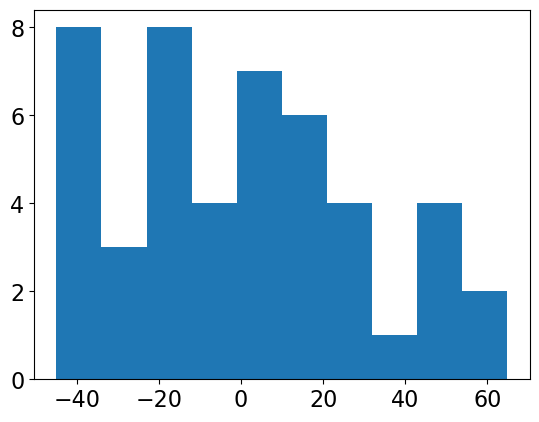

In [150]:
#  Plot historgram of residuals

plt.hist(resids)

Do they look normally distributed? Let's do a test to see:

In [151]:
norm_test = stats.normaltest(resids)
print("p-value is", np.round(norm_test[1],2))

p-value is 0.14


In [152]:
#norm_test

**Reflection Question:**

What does the result of the normal test tell us about whether the residuals are normally distributed?

## Part III: Autocorrelation

Now, let's plot the residuals as a function of the predictor, **TSI**

Text(0, 0.5, "Residuals (100th's of $^{\\circ}$C)")

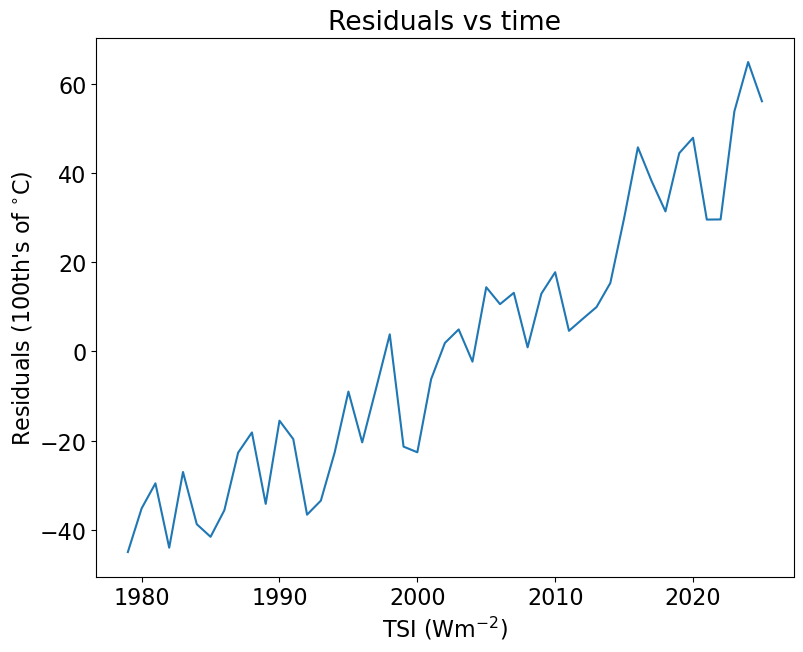

In [153]:
#uncomment and fill in the lines below

plt.figure(figsize=(9,7))
plt.plot(year,resids)
plt.title("Residuals vs time")
plt.xlabel("TSI (Wm$^{-2}$)")
plt.ylabel("Residuals (100th's of $^{\circ}$C)")

Does it look like there is autocorrelation in the residuals? Yes! This is something we don't want.

Let's check.

Let's first think about the meaning of autocorrelation. 

Autocorrelation describes how a variable correlates with itself. It's easiest to think about this in terms of time. For example, how does the weather today relate to the weather yesterday. If we consider a large data set, we can ask a more general question: how does weather on any given day correlate with the weather on the previous day?

For our residuals, this amounts to asking: how does a residual at value $t$+1 correlate with the residual at value $t$ ? We want there to be **very little autocorrelation** in our residuals in order to satisfy the assumptions of linear regression. 

### Lag-zero autocorrelation

First let's check that the residuals at value $t$ correlate perfectly with themselves. We call this the lag-zero autocorrelation.


In [154]:
#  Here's an example using code.

acorr0 = np.corrcoef(resids,resids)[0,1]
print("The lag-zero autocorrelation is ",acorr0, ", almost identically 1!")

The lag-zero autocorrelation is  1.0 , almost identically 1!


### Lag-1 autocorrelation

Now, let's calculate correlation between residuals at value $t$+1 with the residuals at value $t$. We call this the lag-1 autocorrelation

In [155]:
acorr1 = np.corrcoef(resids,np.roll(resids,1))[0,1]
print("The lag-1 autocorrelation is", acorr1)

The lag-1 autocorrelation is 0.8007186684596083


In [156]:
print(resids)
print(np.roll(resids,1))

[-44.95598997 -35.16568142 -29.5528041  -43.98804944 -27.0122446
 -38.72170184 -41.5442037  -35.59259403 -22.67331151 -18.14928364
 -34.16568142 -15.5124119  -19.64138587 -36.58486357 -33.43149367
 -22.67331151  -8.98778177 -20.37483753  -8.35877433   3.85071636
 -21.3268487  -22.59312938  -6.19787472   1.91496914   4.94749703
  -2.27819069  14.40740597  10.61709742  13.15745616   0.93163459
  12.98002493  17.77833162   4.63302678   7.32648774   9.96356023
  15.35061599  29.86671264  45.77019964  38.17351935  31.40740597
  44.46386136  47.91543756  29.5766383   29.60863086  53.8422498
  64.89863827  56.10033159]
[ 56.10033159 -44.95598997 -35.16568142 -29.5528041  -43.98804944
 -27.0122446  -38.72170184 -41.5442037  -35.59259403 -22.67331151
 -18.14928364 -34.16568142 -15.5124119  -19.64138587 -36.58486357
 -33.43149367 -22.67331151  -8.98778177 -20.37483753  -8.35877433
   3.85071636 -21.3268487  -22.59312938  -6.19787472   1.91496914
   4.94749703  -2.27819069  14.40740597  10.617097

### ***Print out `resids` and `np.roll(resids,1)` to be sure that you see what is going on***

### Lag-2 autocorrelation

Now, let's calculate correlation between residuals at value $t$+2 with the residuals at value $t$. We call this the lag-2 autocorrelation


In [157]:
print(resids)
print(np.roll(resids,2))

[-44.95598997 -35.16568142 -29.5528041  -43.98804944 -27.0122446
 -38.72170184 -41.5442037  -35.59259403 -22.67331151 -18.14928364
 -34.16568142 -15.5124119  -19.64138587 -36.58486357 -33.43149367
 -22.67331151  -8.98778177 -20.37483753  -8.35877433   3.85071636
 -21.3268487  -22.59312938  -6.19787472   1.91496914   4.94749703
  -2.27819069  14.40740597  10.61709742  13.15745616   0.93163459
  12.98002493  17.77833162   4.63302678   7.32648774   9.96356023
  15.35061599  29.86671264  45.77019964  38.17351935  31.40740597
  44.46386136  47.91543756  29.5766383   29.60863086  53.8422498
  64.89863827  56.10033159]
[ 64.89863827  56.10033159 -44.95598997 -35.16568142 -29.5528041
 -43.98804944 -27.0122446  -38.72170184 -41.5442037  -35.59259403
 -22.67331151 -18.14928364 -34.16568142 -15.5124119  -19.64138587
 -36.58486357 -33.43149367 -22.67331151  -8.98778177 -20.37483753
  -8.35877433   3.85071636 -21.3268487  -22.59312938  -6.19787472
   1.91496914   4.94749703  -2.27819069  14.4074059

In [158]:
acorr2 = np.corrcoef(resids,np.roll(resids,2))[0,1]
print("The lag-2 autocorrelation is", acorr2)

The lag-2 autocorrelation is 0.6269784708804399


### Autocorrelation for all lags

Now, we can do the same thing for every combination, i.e. at all lags. We will go over the code below in detail in the courseware. For now, it is important that you understand the concept of autocorrelation.

In [159]:
#  This line uses np.correlate to calculate the autocorrelation at all lags.
#  E.g., the residuals at value t with all the residuals from values t-N/2 to t+N/2

acorr = np.correlate(resids/(np.std(resids)),resids/(np.std(resids)*len(resids)),'same')

In [160]:
print(acorr.shape)

(47,)


In [161]:
#  We can do the same thing for temperature - calculate the correlation of T with itself at all lags
Tcorr = np.correlate((T-np.mean(T))/(np.std(T)),(T-np.mean(T))/(np.std(T)*len(T)),'same')

In [162]:
#  And TSI
TSIcorr = np.correlate((TSI-np.mean(TSI))/(np.std(TSI)),(TSI-np.mean(TSI))/(np.std(TSI)*len(TSI)),'same')

Now, let's plot the autocorrelation functions as a function of lag.

In [163]:
#  Here I am creating a t-index of lags from -N/2 to +N/2 in order to plot the autocorrelation, acorr2

t = np.arange(0,len(resids),1)
lag = [i-len(resids)/2 +0.5 for i in t]
#print(lag)   #uncomment this line to see what series looks like

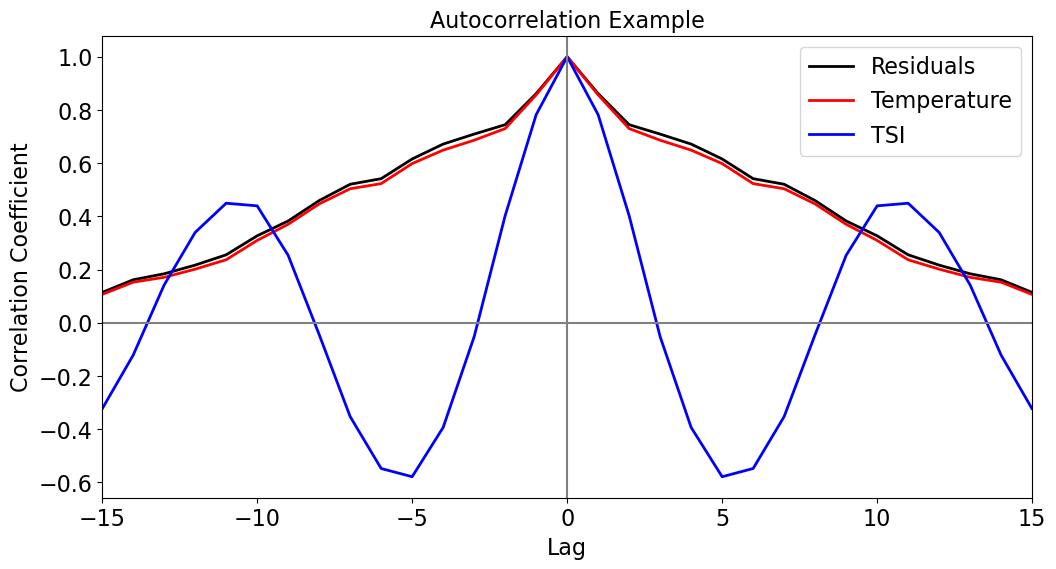

In [164]:
#plot the autocorrelation as a function of lag
fig = plt.figure(figsize=(12,6))

plt.plot(lag,acorr,'k',linewidth=2,label='Residuals') #uncomment and fill in this line
plt.plot(lag,Tcorr,'r',linewidth=2,label='Temperature') 
plt.plot(lag,TSIcorr,'b',linewidth=2,label='TSI') 
plt.axhline(0,color='gray')
plt.axvline(0,color='gray')
plt.xlim(-15,15)
plt.title("Autocorrelation Example",fontsize=16)
plt.xlabel('Lag',fontsize=16)
plt.ylabel('Correlation Coefficient',fontsize=16)
plt.legend(fontsize=16)     #uncomment this line
plt.savefig('autocorr_example.png')

What do you see in this figure? Do our residuals have autocorrelation? Where is the autocorrelation coming from?

We can verify whether or not the residuals have autocorrelation using the Durbin Watson test:

In [165]:
#  test for autocorrelation of residuals
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(resids)
print(dw)

0.1531594787590625


## Part IV: Filtering

(You will learn more about this in this week's courseware readings.)

Based on the above analysis, we can see that the residuals have autocorrelation. This stems from the strong trend in the temperature data. We also know from In-Class Assessment 3, that there is a strong relationship between $T$ and CO$_2$. 

So, we can try to remove the autocorrelation by first
- removing the temporal trend in $T$ or 
- removing the relationship between $T$ and CO$_2$

before we perform the regression between $T$ and **TSI**

The first option makes more intuitive sense, so let's try that.

We start by computing the trend in $T$ using regression:

In [166]:
#  calculate the best-fit value for T as a function of year

a = np.polyfit(year,T,1)
T_hat2 = np.polyval(a,year)

Then, we substract this best-fit line from $T$ - this is the *detrended* temperature.

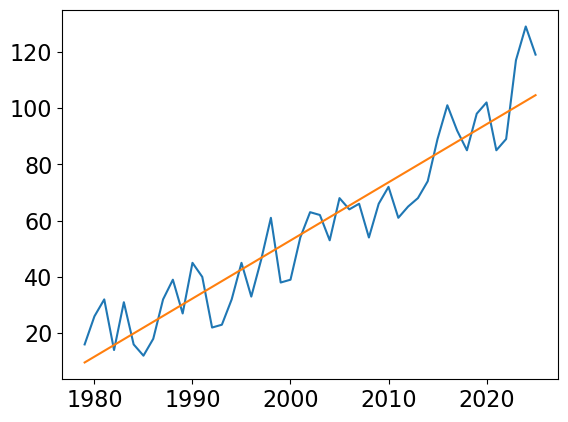

In [167]:

plt.plot(year,T)
plt.plot(year,T_hat2)

In [168]:
#  compute the detrended temperature
T_dtr = T - T_hat2

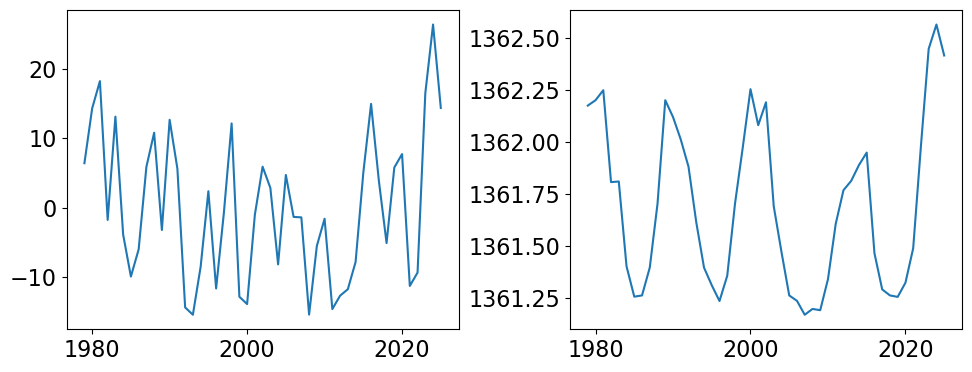

In [169]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(year,T_dtr)
plt.subplot(1,2,2)
plt.plot(year,TSI)
plt.tight_layout()

Now, repeat the regression between $T$ and **TSI**, but this time using $T_{dtr}$ rather than $T$.

**Reflection Question:**

Do the residuals still have autocorrelation? How do you know?

In [170]:
#  calculate the best-fit value for T_dtr as a function of TSI

a = np.polyfit(TSI,T_dtr,1)
T_hat3 = np.polyval(a,TSI)

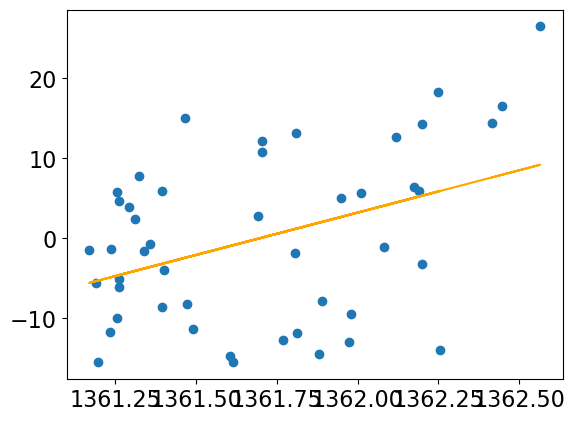

In [171]:
plt.scatter(TSI,T_dtr)
plt.plot(TSI,T_hat3,'orange')

In [172]:
pcorr = stats.pearsonr(TSI,T_dtr)
print(pcorr)

PearsonRResult(statistic=0.4006450834360917, pvalue=0.005259841735086515)


In [173]:
resids2 = T_dtr - T_hat3

We can use the Durbin-Watson test for autocorrelation...

In [192]:
dw = durbin_watson(resids2) # output ranges from 0 to 4, with values close to 0 indicating autocorrelation
print(dw)

1.408304640831271


this tells us that there is a low likelihood of autocorrelation...but, I prefer to plot the autocorrelation function to better understand what the autocorrelation looks like.

In [175]:
#  This line uses np.correlate to calculate the autocorrelation at all lags.
#  E.g., the residuals at value t with all the residuals from values t-N/2 to t+N/2

acorr2 = np.correlate(resids2/(np.std(resids2)),resids2/(np.std(resids2)*len(resids2)),'same')

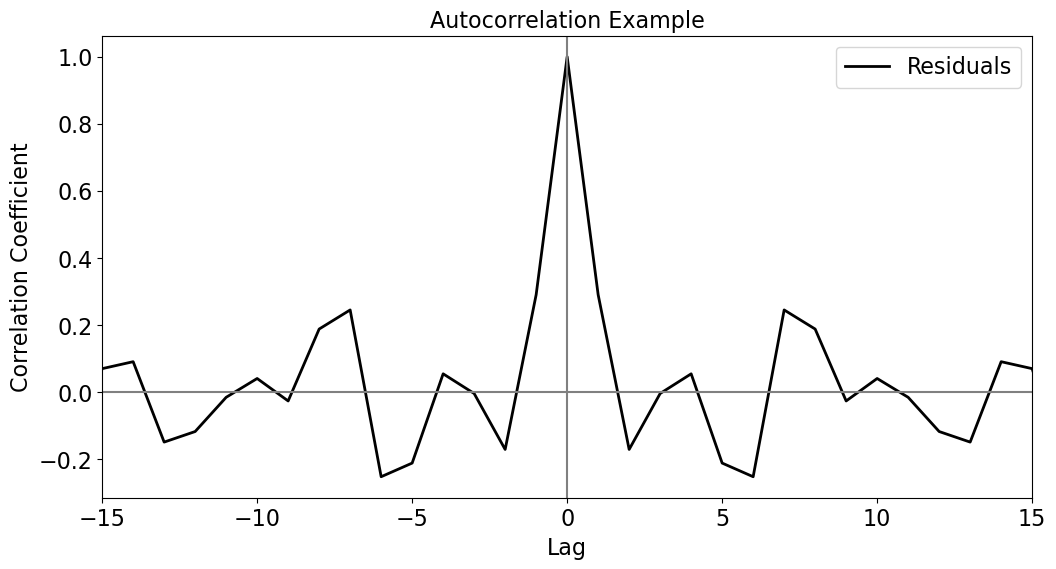

In [176]:
#plot the autocorrelation as a function of lag
fig = plt.figure(figsize=(12,6))

plt.plot(lag,acorr2,'k',linewidth=2,label='Residuals') #uncomment and fill in this line
plt.axhline(0,color='gray')
plt.axvline(0,color='gray')
plt.xlim(-15,15)
plt.title("Autocorrelation Example",fontsize=16)
plt.xlabel('Lag',fontsize=16)
plt.ylabel('Correlation Coefficient',fontsize=16)
plt.legend(fontsize=16)     #uncomment this line

Now, we can try to detrend temperature using CO2. You'll find that you get a very similar answer.

In [177]:
# define CO2 data
CO2 = data[2]
print(CO2)

[336.84 338.76 340.12 341.48 343.15 344.85 346.35 347.61 349.31 351.69
 353.2  354.45 355.7  356.54 357.21 358.96 360.97 362.74 363.88 366.84
 368.54 369.71 371.32 373.45 375.98 377.7  379.98 382.09 384.03 385.83
 387.64 390.1  391.85 394.06 396.74 398.87 401.01 404.41 406.76 408.72
 411.66 414.24 416.41 418.53 421.08 424.61 427.35]


In [178]:
#  calculate the best-fit value for T as a function of CO2

a = np.polyfit(CO2,T,1)
T_hat4 = np.polyval(a,CO2)

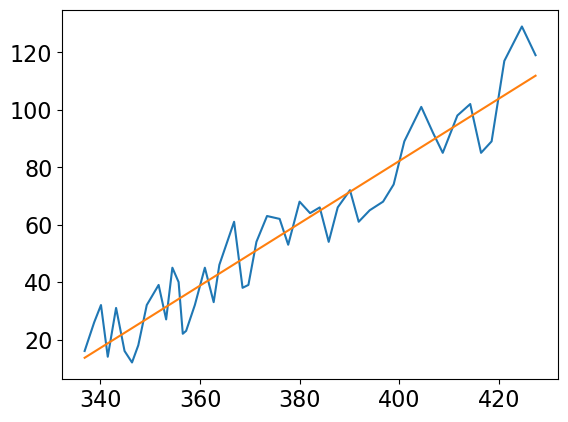

In [179]:
# visualize
plt.plot(CO2,T)
plt.plot(CO2,T_hat4)

In [180]:
#  compute the detrended temperature

T_dtr2 = T - T_hat4

In [181]:
#  calculate the best-fit value for T_dtr as a function of TSI

a = np.polyfit(TSI,T_dtr2,1)
T_hat5 = np.polyval(a,TSI)

In [182]:
#  compute correlation coefficient

pcorr = stats.pearsonr(TSI,T_dtr2)
print(pcorr)

PearsonRResult(statistic=0.33159333270550406, pvalue=0.02279114394463658)


In [183]:
#  calculate residuals

resids3 = T_dtr2 - T_hat5

In [184]:
#  This line uses np.correlate to calculate the autocorrelation at all lags.
#  E.g., the residuals at value t with all the residuals from values t-N/2 to t+N/2

acorr3 = np.correlate(resids3/(np.std(resids3)),resids3/(np.std(resids3)*len(resids3)),'same')

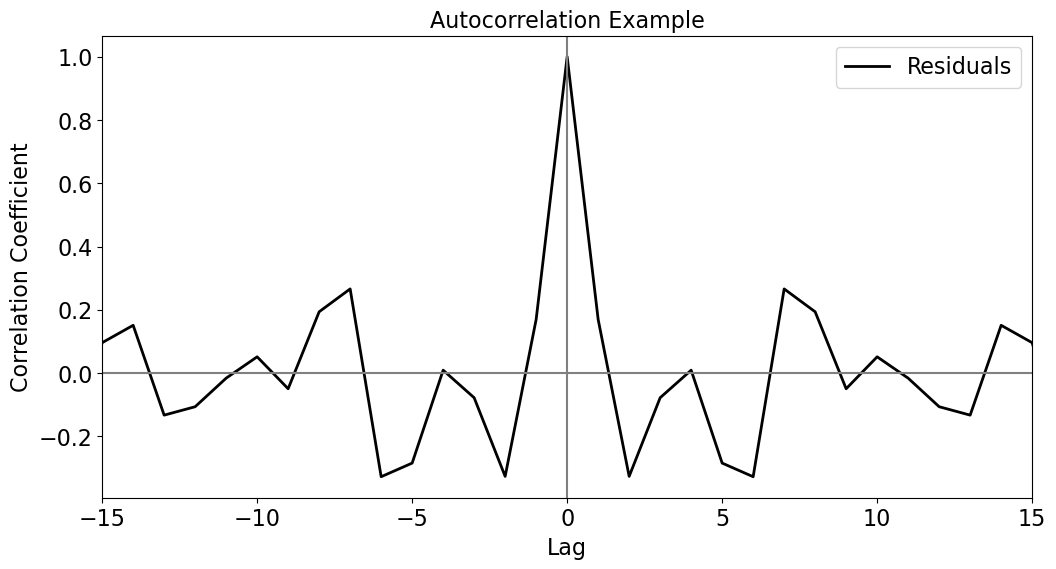

In [185]:
#plot the autocorrelation as a function of lag
fig = plt.figure(figsize=(12,6))

plt.plot(lag,acorr3,'k',linewidth=2,label='Residuals') #uncomment and fill in this line
plt.axhline(0,color='gray')
plt.axvline(0,color='gray')
plt.xlim(-15,15)
plt.title("Autocorrelation Example",fontsize=16)
plt.xlabel('Lag',fontsize=16)
plt.ylabel('Correlation Coefficient',fontsize=16)
plt.legend(fontsize=16)     #uncomment this line

In [186]:
dw = durbin_watson(resids3)
print(dw)

1.6595405059837414
